# Deep Hedging with pfhedge

**Docker image**: `ml4t-py312`

> **`ml4t-py312` image required.** `pfhedge` is an unmaintained package pinned
> to `numpy<2`, so it only ships in the Python-3.12 image rather than the
> main `ml4t` image:
>
> ```bash
> docker compose --profile py312 run --rm py312 \
>     python 21_rl_execution_hedging/05_deep_hedging_pfhedge.py
> ```


This notebook demonstrates the Deep Hedging framework for derivative risk
management, learning hedging policies that control tail risk under
transaction costs.

**Learning Outcomes**:
- LO4: Build a deep hedging system and compare it with delta hedging under costs
- LO8: Design reward functions incorporating expected shortfall and transaction costs

**Book Reference**: Chapter 21, Section 21.6.

**Prerequisites**: Chapter 19 risk measures and the `environments` module.

In [1]:
"""Deep Hedging with pfhedge - Learn hedging policies under transaction costs."""

# Core imports
import warnings

import numpy as np
import polars as pl

warnings.filterwarnings("ignore")

# Visualization
import plotly.graph_objects as go

# PyTorch
import torch
import torch.nn as nn

# pfhedge for deep hedging - ships only in the py312 image.
try:
    import pfhedge
    from pfhedge.instruments import BrownianStock, EuropeanOption, HestonStock
    from pfhedge.nn import (
        BlackScholes,
        ExpectedShortfall,
        Hedger,
        MultiLayerPerceptron,
        WhalleyWilmott,
    )
except ImportError as exc:
    raise ImportError(
        "`pfhedge` is not available in the current image.\n"
        "This notebook runs in the `ml4t-py312` image:\n"
        "  docker compose --profile py312 run --rm py312 \\\n"
        "      python 21_rl_execution_hedging/05_deep_hedging_pfhedge.py"
    ) from exc

print(f"pfhedge version: {pfhedge.__version__}")

# ML4T paths
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

pfhedge version: 0.23.0


In [2]:
OUTPUT_DIR = get_output_dir(21, "deep_hedging_pfhedge")

In [3]:
N_PATHS = 10_000
N_STEPS = 20
MATURITY = 30 / 365
SPOT = 100.0
STRIKE = 100.0
VOLATILITY = 0.20
COST_BPS = 10
N_EPOCHS = 200
SCENARIO_MODEL = "heston"
EXPECTED_SHORTFALL_Q = 0.05
SEED = 42  # base seed; per-restart seeds in TRAINING_SEEDS
TRAINING_SEEDS = [42, 314, 2718]
EVAL_SEED = 999
VALIDATION_SEED = 777
WHALLEY_WILMOTT_RISK_AVERSION = 1.0
HESTON_KAPPA = 1.5
HESTON_THETA = VOLATILITY**2
HESTON_SIGMA = 0.35
HESTON_RHO = -0.7
EXPORT_RESULTS = False
# The from-scratch GBM deep hedger in Section 2 is an optional reference check,
# not part of the four-method Heston comparison. Off by default so it does not
# enter the headline summary table; set True to run the GBM sanity check.
RUN_REFERENCE_IMPL = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration
config = {
    "n_paths": N_PATHS,
    "n_steps": N_STEPS,
    "maturity": MATURITY,  # 30 days
    "spot": SPOT,
    "strike": STRIKE,
    "volatility": VOLATILITY,
    "cost_bps": COST_BPS,  # 10 bps transaction cost
    "n_epochs": N_EPOCHS,
    "scenario_model": SCENARIO_MODEL,
    "expected_shortfall_q": EXPECTED_SHORTFALL_Q,
    "training_seeds": TRAINING_SEEDS,
    "eval_seed": EVAL_SEED,
    "validation_seed": VALIDATION_SEED,
    "ww_risk_aversion": WHALLEY_WILMOTT_RISK_AVERSION,
    "heston_kappa": HESTON_KAPPA,
    "heston_theta": HESTON_THETA,
    "heston_sigma": HESTON_SIGMA,
    "heston_rho": HESTON_RHO,
    "export_results": EXPORT_RESULTS,
    "run_reference_impl": RUN_REFERENCE_IMPL,
    "device": DEVICE,
}

PFHEDGE_COST_RATE = config["cost_bps"] / 10_000
PFHEDGE_STRIKE = config["strike"] / config["spot"]
PFHEDGE_DT = config["maturity"] / config["n_steps"]

print(f"Configuration: {config}")

Configuration: {'n_paths': 10000, 'n_steps': 20, 'maturity': 0.0821917808219178, 'spot': 100.0, 'strike': 100.0, 'volatility': 0.2, 'cost_bps': 10, 'n_epochs': 200, 'scenario_model': 'heston', 'expected_shortfall_q': 0.05, 'training_seeds': [42, 314, 2718], 'eval_seed': 999, 'validation_seed': 777, 'ww_risk_aversion': 1.0, 'heston_kappa': 1.5, 'heston_theta': 0.04000000000000001, 'heston_sigma': 0.35, 'heston_rho': -0.7, 'export_results': False, 'run_reference_impl': False, 'device': 'cuda'}


## 1. Deep Hedging with pfhedge

We use the `pfhedge` implementation with an expected-shortfall objective and
compare it against analytical friction-aware baselines (Black-Scholes delta,
Whalley-Wilmott). Section 2 defines a from-scratch PyTorch implementation
that is trained and evaluated on GBM paths in Section 3b as a reference
check; the pfhedge Heston-stock run here remains the primary measurement.

In [6]:
criterion = ExpectedShortfall(config["expected_shortfall_q"]).to(config["device"])

`build_underlier` constructs the stochastic-volatility (Heston) or
geometric-Brownian underlier with the configured cost and time step.

In [7]:
def build_underlier() -> BrownianStock | HestonStock:
    if config["scenario_model"] == "heston":
        return HestonStock(
            kappa=config["heston_kappa"],
            theta=config["heston_theta"],
            sigma=config["heston_sigma"],
            rho=config["heston_rho"],
            cost=PFHEDGE_COST_RATE,
            dt=PFHEDGE_DT,
            device=config["device"],
        )
    return BrownianStock(
        sigma=config["volatility"],
        cost=PFHEDGE_COST_RATE,
        dt=PFHEDGE_DT,
    ).to(config["device"])

`build_option` wraps the underlier in the European call we hedge.

In [8]:
def build_option(stock: BrownianStock | HestonStock) -> EuropeanOption:
    return EuropeanOption(stock, maturity=config["maturity"], strike=PFHEDGE_STRIKE).to(
        device=config["device"]
    )

`simulate_option` seeds the RNG and draws `n_paths` price paths for a fresh
option instance - used to produce independent train and evaluation sets.

In [9]:
def simulate_option(seed: int, n_paths: int) -> EuropeanOption:
    torch.manual_seed(seed)
    simulated_option = build_option(build_underlier())
    simulated_option.simulate(n_paths=n_paths)
    return simulated_option

`build_deep_hedger` assembles the pfhedge MLP hedger with the
expected-shortfall criterion.

In [10]:
def build_deep_hedger() -> Hedger:
    return Hedger(
        model=MultiLayerPerceptron(in_features=4, out_features=1),
        inputs=["log_moneyness", "time_to_maturity", "volatility", "prev_hedge"],
        criterion=criterion,
    ).to(config["device"])

In [11]:
print("pfhedge setup complete")
print(
    f"Scenario model: {config['scenario_model']}, criterion: Expected Shortfall "
    f"({config['expected_shortfall_q']:.0%})"
)
print(
    f"Training with {config['n_paths']} paths, {config['n_epochs']} epochs, "
    f"{len(config['training_seeds'])} seed(s)"
)

pfhedge setup complete
Scenario model: heston, criterion: Expected Shortfall (5%)
Training with 10000 paths, 200 epochs, 3 seed(s)


## 2. Custom Deep Hedging Implementation (Reference)

This section defines a from-scratch deep hedger for readers who want to see
the mechanics outside the `pfhedge` library. The network maps the state vector
$(\log(S/K),\; \tau,\; \sigma,\; \delta_{\text{prev}})$ to a hedge position
$\delta \in [0, 1]$ via a sigmoid output and trains by minimizing an
expected-shortfall surrogate over terminal P&L. The implementation is
invoked in Section 3b on GBM paths (its native model) as a sanity check that
the from-scratch training loop converges to a coherent hedger; the §6
summary table reports its P&L statistics alongside the pfhedge run.

### Hedger Network

A three-layer MLP with sigmoid output constraining the hedge ratio to $[0, 1]$.

In [12]:
class CustomDeepHedger(nn.Module):
    """
    Custom deep hedging network.

    Inputs: [log_moneyness, time_to_maturity, volatility, prev_hedge]
    Output: hedge_position (delta equivalent)
    """

    def __init__(self, hidden_size: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid(),  # Output in [0, 1] for call delta
        )

    def forward(self, x):
        return self.net(x)

### Simulate GBM Price Paths

Generate Monte Carlo paths under geometric Brownian motion for training
and evaluation. The discrete-time dynamics follow:

$$\log S_{t+1} - \log S_t = -\tfrac{1}{2}\sigma^2 \Delta t + \sigma \sqrt{\Delta t}\, Z_t, \quad Z_t \sim \mathcal{N}(0,1)$$

In [13]:
def simulate_gbm_paths(
    spot: float,
    volatility: float,
    maturity: float,
    n_steps: int,
    n_paths: int,
    seed: int = 42,
) -> torch.Tensor:
    """Simulate GBM paths."""
    torch.manual_seed(seed)
    dt = maturity / n_steps

    # Generate returns
    z = torch.randn(n_paths, n_steps, device=config["device"])
    log_returns = -0.5 * volatility**2 * dt + volatility * np.sqrt(dt) * z

    # Cumulative sum to get prices
    log_prices = torch.cumsum(log_returns, dim=1)
    log_prices = torch.cat([torch.zeros(n_paths, 1, device=config["device"]), log_prices], dim=1)
    prices = spot * torch.exp(log_prices)

    return prices

### Black-Scholes Delta and Call Payoff

The analytical delta for a European call is the benchmark hedging strategy:

$$\Delta = \Phi(d_1), \quad d_1 = \frac{\ln(S/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

where $\Phi$ is the standard normal CDF.

In [14]:
def black_scholes_delta(S, K, T, sigma):
    """Black-Scholes delta for a call option."""
    from scipy.stats import norm

    if T <= 0:
        return np.where(S > K, 1.0, 0.0)

    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

In [15]:
def terminal_call_payoff(prices: np.ndarray, strike: float) -> np.ndarray:
    """European call payoff at maturity."""
    return np.maximum(prices[:, -1] - strike, 0.0)

### Self-Financing P&L (NumPy)

Compute the hedging P&L under proportional transaction costs using the
self-financing convention: trading gains minus costs minus option payoff.

In [16]:
def hedging_pnl_from_positions(
    prices: np.ndarray,
    positions: np.ndarray,
    strike: float,
    cost_rate: float,
) -> np.ndarray:
    """Compute self-financing P&L using the pfhedge convention."""
    if positions.shape != prices[:, :-1].shape:
        raise ValueError(f"Expected positions shape {prices[:, :-1].shape}, got {positions.shape}")

    dS = np.diff(prices, axis=1)
    previous_positions = np.concatenate(
        [np.zeros((positions.shape[0], 1)), positions[:, :-1]], axis=1
    )
    trade_sizes = positions - previous_positions
    trading_pnl = (positions * dS).sum(axis=1)
    transaction_costs = (np.abs(trade_sizes) * prices[:, :-1]).sum(axis=1) * cost_rate
    return trading_pnl - transaction_costs - terminal_call_payoff(prices, strike)

### Self-Financing P&L (PyTorch)

Differentiable version of the same P&L calculation, enabling backpropagation
through the hedging loss for the custom deep hedging training loop.

In [17]:
def hedging_pnl_from_positions_torch(
    prices: torch.Tensor,
    positions: torch.Tensor,
    strike: float,
    cost_rate: float,
) -> torch.Tensor:
    """Torch version of the pfhedge self-financing P&L."""
    if positions.shape != prices[:, :-1].shape:
        raise ValueError(f"Expected positions shape {prices[:, :-1].shape}, got {positions.shape}")

    dS = prices[:, 1:] - prices[:, :-1]
    previous_positions = torch.cat([torch.zeros_like(positions[:, :1]), positions[:, :-1]], dim=1)
    trade_sizes = positions - previous_positions
    trading_pnl = (positions * dS).sum(dim=1)
    transaction_costs = (trade_sizes.abs() * prices[:, :-1]).sum(dim=1) * cost_rate
    payoff = torch.relu(prices[:, -1] - strike)
    return trading_pnl - transaction_costs - payoff

### P&L Summary Statistics

Compute tail-risk metrics (5% CVaR) alongside standard moments for
comparing hedging strategies.

In [18]:
def pnl_stats(pnl: np.ndarray) -> dict:
    cvar_cutoff = np.percentile(pnl, 5)
    return {
        "mean": np.mean(pnl),
        "std": np.std(pnl),
        "cvar_5": np.mean(pnl[pnl <= cvar_cutoff]),
        "max_loss": np.min(pnl),
    }

### Custom Training Loop

End-to-end training: roll the hedger through simulated GBM paths, compute
terminal P&L including transaction costs, and minimize a tail-risk surrogate.

In [19]:
def expected_shortfall_loss_torch(pnl: torch.Tensor, quantile: float) -> torch.Tensor:
    """Approximate expected shortfall of P&L at the given quantile."""
    cutoff = torch.quantile(pnl, quantile)
    tail = pnl[pnl <= cutoff]
    if tail.numel() == 0:
        return -pnl.mean()
    return -tail.mean()

### Custom Deep Hedging Training Loop

End-to-end training: roll the hedger through simulated GBM paths, compute
terminal P&L including transaction costs, and minimize the expected shortfall.

The differentiable rollout converts each simulated path into a complete hedge
position matrix before the tail-risk objective is evaluated.

In [20]:
def custom_hedge_positions(model: nn.Module, prices: torch.Tensor) -> torch.Tensor:
    """Roll the custom network through every hedge date."""
    n_paths, n_times = prices.shape
    dt = config["maturity"] / config["n_steps"]
    hedge = torch.zeros(n_paths, device=config["device"])
    hedge_path = []
    for t in range(n_times - 1):
        spot = prices[:, t]
        features = torch.stack(
            [
                torch.log(spot / config["strike"]),
                torch.full_like(spot, config["maturity"] - t * dt),
                torch.full_like(spot, config["volatility"]),
                hedge,
            ],
            dim=1,
        )
        hedge = model(features).squeeze()
        hedge_path.append(hedge)
    return torch.stack(hedge_path, dim=1)

In [21]:
def run_custom_deep_hedging(seed: int):
    """Run deep hedging with custom implementation."""
    prices = simulate_gbm_paths(
        spot=config["spot"],
        volatility=config["volatility"],
        maturity=config["maturity"],
        n_steps=config["n_steps"],
        n_paths=config["n_paths"],
        seed=seed,
    )
    cost_rate = config["cost_bps"] / 10_000

    model = CustomDeepHedger().to(config["device"])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []

    for epoch in range(config["n_epochs"]):
        optimizer.zero_grad()
        pnl = hedging_pnl_from_positions_torch(
            prices=prices,
            positions=custom_hedge_positions(model, prices),
            strike=config["strike"],
            cost_rate=cost_rate,
        )

        loss = expected_shortfall_loss_torch(pnl, config["expected_shortfall_q"])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1}/{config['n_epochs']}, Loss: {loss.item():.4f}")

    return model, prices, losses

## 3. Train Deep Hedging Model

We train across multiple seeds and select the run whose expected shortfall is
closest to the median on an independent validation set. The final evaluation
paths remain sealed until after selection.

In [22]:
# Build independent validation and evaluation paths, then train across seeds.
validation_option = simulate_option(config["validation_seed"], config["n_paths"])
eval_option = simulate_option(config["eval_seed"], config["n_paths"])
bs_model = BlackScholes(eval_option).to(config["device"])
bs_hedger = Hedger(bs_model, bs_model.inputs()).to(config["device"])
ww_model = WhalleyWilmott(eval_option, a=config["ww_risk_aversion"]).to(config["device"])
ww_hedger = Hedger(ww_model, ww_model.inputs(), criterion=criterion).to(config["device"])

deep_seed_runs = []
for seed in config["training_seeds"]:
    print(f"\nTraining seed {seed}...")
    train_option = simulate_option(seed, config["n_paths"])
    seed_hedger = build_deep_hedger()
    seed_hedger.fit(
        train_option,
        n_epochs=config["n_epochs"],
        n_paths=config["n_paths"],
        verbose=False,
    )

    validation_pnl = (
        seed_hedger.compute_pl(validation_option).detach().cpu().numpy() * config["spot"]
    )
    validation_stats = pnl_stats(validation_pnl)
    deep_seed_runs.append(
        {
            "seed": seed,
            "hedger": seed_hedger,
            "validation_pnl": validation_pnl,
            "validation_stats": validation_stats,
        }
    )
    print(
        f"Seed {seed}: validation mean={validation_stats['mean']:.4f}, "
        f"std={validation_stats['std']:.4f}, CVaR={validation_stats['cvar_5']:.4f}"
    )


Training seed 42...


Seed 42: validation mean=-2.3593, std=0.9268, CVaR=-4.3251

Training seed 314...


Seed 314: validation mean=-2.4050, std=0.7607, CVaR=-3.9326

Training seed 2718...


Seed 2718: validation mean=-2.3698, std=0.8573, CVaR=-4.1455


### Select Representative Seed

Pick the training seed whose validation CVaR is closest to the median across
all seeds, without inspecting the final evaluation paths.

In [23]:
deep_seed_summary = pl.DataFrame(
    [
        {
            "seed": run["seed"],
            "validation_mean_pnl": float(run["validation_stats"]["mean"]),
            "validation_std_pnl": float(run["validation_stats"]["std"]),
            "validation_cvar_5": float(run["validation_stats"]["cvar_5"]),
            "validation_max_loss": float(run["validation_stats"]["max_loss"]),
        }
        for run in deep_seed_runs
    ]
).sort("seed")
target_cvar = float(deep_seed_summary["validation_cvar_5"].median())
representative_seed = int(
    deep_seed_summary.with_columns(
        (pl.col("validation_cvar_5") - target_cvar).abs().alias("distance_to_median_cvar")
    ).sort(["distance_to_median_cvar", "seed"])["seed"][0]
)
representative_run = next(run for run in deep_seed_runs if run["seed"] == representative_seed)
hedger = representative_run["hedger"]
deep_pnl = hedger.compute_pl(eval_option).detach().cpu().numpy() * config["spot"]
deep_stats = pnl_stats(deep_pnl)

print(f"Representative deep-hedging seed: {representative_seed}")
print("\nDeep-hedging seed stability:")
deep_seed_summary

Representative deep-hedging seed: 2718

Deep-hedging seed stability:


seed,validation_mean_pnl,validation_std_pnl,validation_cvar_5,validation_max_loss
i64,f64,f64,f64,f64
42,-2.359337,0.92678,-4.325055,-6.16352
314,-2.404974,0.760704,-3.932636,-5.705587
2718,-2.369841,0.857255,-4.14551,-5.644684


## 3b. From-Scratch Reference Run on GBM Paths (optional)

When `RUN_REFERENCE_IMPL` is enabled, train the `CustomDeepHedger` defined in
§2 once at the representative seed on GBM paths with the same volatility,
maturity, strike, and cost rate. The from-scratch model assumes
constant-volatility GBM, so it is trained and evaluated on its native model,
a convergence sanity check on the §2 implementation, **not** a head-to-head
against the pfhedge Heston run. Because the two use different stochastic
models it is excluded from the §6 four-method comparison by default; set
`RUN_REFERENCE_IMPL = True` to compute and display it.

Evaluation rolls the fitted custom network over a fresh GBM draw and applies
the same self-financing P&L convention used during training.

In [24]:
def evaluate_custom_hedger(model: nn.Module, prices: torch.Tensor) -> np.ndarray:
    """Evaluate the custom network on independent paths."""
    model.eval()
    with torch.no_grad():
        positions = custom_hedge_positions(model, prices)
        pnl = hedging_pnl_from_positions_torch(
            prices=prices,
            positions=positions,
            strike=config["strike"],
            cost_rate=config["cost_bps"] / 10_000,
        )
    return pnl.detach().cpu().numpy()

In [25]:
custom_stats = None
custom_pnl = None
if config["run_reference_impl"]:
    print(f"\nTraining CustomDeepHedger (reference, GBM) at seed {representative_seed}...")
    custom_model, _, _ = run_custom_deep_hedging(seed=representative_seed)

    # Independent GBM evaluation paths
    custom_eval_prices = simulate_gbm_paths(
        spot=config["spot"],
        volatility=config["volatility"],
        maturity=config["maturity"],
        n_steps=config["n_steps"],
        n_paths=config["n_paths"],
        seed=config["eval_seed"],
    )

    custom_pnl = evaluate_custom_hedger(custom_model, custom_eval_prices)
    custom_stats = pnl_stats(custom_pnl)
    print(
        f"CustomDeepHedger (GBM eval): mean={custom_stats['mean']:.4f}, "
        f"std={custom_stats['std']:.4f}, CVaR={custom_stats['cvar_5']:.4f}, "
        f"max_loss={custom_stats['max_loss']:.4f}"
    )
else:
    print("Reference from-scratch GBM hedger skipped (RUN_REFERENCE_IMPL=False).")

Reference from-scratch GBM hedger skipped (RUN_REFERENCE_IMPL=False).


## 4. Compare with Analytical and Value-Based Benchmarks

### Delta Hedging P&L Simulator

Simulate the classical delta-neutral strategy: at each rebalancing step,
set the hedge ratio to the Black-Scholes delta and pay proportional
transaction costs on each trade. All methods below are evaluated on the
same simulated paths using the self-financing convention implemented by
`pfhedge.nn.functional.pl`.

In [26]:
def delta_hedging_pnl(
    prices: np.ndarray,
    strike: float,
    volatility: float | np.ndarray,
    maturity: float,
    cost_rate: float,
) -> np.ndarray:
    """Simulate delta hedging and compute P&L distribution."""
    n_paths, n_times = prices.shape
    dt = maturity / (n_times - 1)
    positions = np.zeros((n_paths, n_times - 1))

    for path_idx in range(n_paths):
        S = prices[path_idx]
        for t in range(n_times - 1):
            sigma = volatility[path_idx, t] if isinstance(volatility, np.ndarray) else volatility
            positions[path_idx, t] = black_scholes_delta(S[t], strike, maturity - t * dt, sigma)

    return hedging_pnl_from_positions(
        prices=prices,
        positions=positions,
        strike=strike,
        cost_rate=cost_rate,
    )

In [27]:
# Generate matched evaluation paths
test_prices = eval_option.ul().spot.detach().cpu().numpy() * config["spot"]
test_volatility = eval_option.ul().volatility.detach().cpu().numpy()

In [28]:
# Compute baseline P&L distributions
delta_pnl = bs_hedger.compute_pl(eval_option).detach().cpu().numpy() * config["spot"]
ww_pnl = ww_hedger.compute_pl(eval_option).detach().cpu().numpy() * config["spot"]

delta_stats = pnl_stats(delta_pnl)
print(
    f"Delta Hedging - Mean: {delta_stats['mean']:.4f}, Std: {delta_stats['std']:.4f}, "
    f"5% CVaR: {delta_stats['cvar_5']:.4f}"
)

if ww_pnl is not None:
    ww_stats = pnl_stats(ww_pnl)
    print(
        f"Whalley-Wilmott - Mean: {ww_stats['mean']:.4f}, Std: {ww_stats['std']:.4f}, "
        f"5% CVaR: {ww_stats['cvar_5']:.4f}"
    )

Delta Hedging - Mean: -2.4488, Std: 0.5302, 5% CVaR: -3.7339
Whalley-Wilmott - Mean: -2.3387, Std: 1.6112, 5% CVaR: -5.3616


### Deep Hedging P&L on Test Paths

Roll the trained deep hedger through held-out paths using the same
self-financing accounting convention as the delta hedge baseline.

In [29]:
# Report deep hedger P&L on the held-out evaluation paths
print(
    f"Deep Hedging - Mean: {deep_stats['mean']:.4f}, Std: {deep_stats['std']:.4f}, "
    f"5% CVaR: {deep_stats['cvar_5']:.4f}"
)

Deep Hedging - Mean: -2.3854, Std: 0.8698, 5% CVaR: -4.1788


## 5. Visualize P&L Distributions

An empirical CDF preserves the loss tails that overlapping histograms obscure.
Curves farther to the right represent less-negative P&L at the same percentile.

In [30]:
def ecdf_xy(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sorted values and cumulative probabilities for an empirical CDF."""
    x = np.sort(np.asarray(values))
    return x, np.arange(1, len(x) + 1) / len(x)

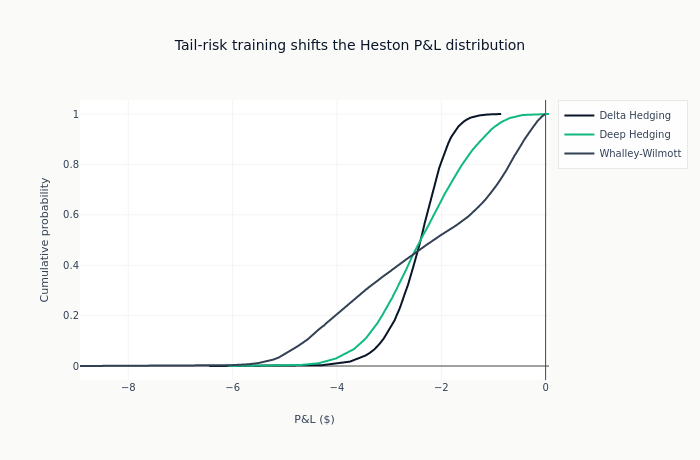

In [31]:
fig = go.Figure()
tail_methods = {"Delta Hedging": delta_pnl, "Deep Hedging": deep_pnl}
if ww_pnl is not None:
    tail_methods["Whalley-Wilmott"] = ww_pnl
tail_colors = {
    "Delta Hedging": COLORS["blue"],
    "Deep Hedging": COLORS["positive"],
    "Whalley-Wilmott": COLORS["neutral"],
}
for name, pnl in tail_methods.items():
    x, y = ecdf_xy(pnl)
    fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name=name, line_color=tail_colors[name]))

fig.update_layout(
    title="Tail-risk training shifts the Heston P&L distribution",
    xaxis_title="P&L ($)",
    yaxis_title="Cumulative probability",
    height=460,
)
fig.show()

## 6. Summary Statistics

In [32]:
summary = []

summary.append(
    {
        "Strategy": "Delta Hedging [Heston]",
        "Mean P&L": f"{np.mean(delta_pnl):.4f}",
        "Std Dev": f"{np.std(delta_pnl):.4f}",
        "5% CVaR": f"{np.mean(delta_pnl[delta_pnl <= np.percentile(delta_pnl, 5)]):.4f}",
        "Max Loss": f"{np.min(delta_pnl):.4f}",
    }
)

if ww_pnl is not None:
    summary.append(
        {
            "Strategy": "Whalley-Wilmott [Heston]",
            "Mean P&L": f"{ww_stats['mean']:.4f}",
            "Std Dev": f"{ww_stats['std']:.4f}",
            "5% CVaR": f"{ww_stats['cvar_5']:.4f}",
            "Max Loss": f"{ww_stats['max_loss']:.4f}",
        }
    )

Learned-model rows use the same P&L statistics and preserve the simulator
label so Heston and optional GBM results are not conflated.

In [33]:
summary.append(
    {
        "Strategy": "pfhedge Deep Hedging [Heston]",
        "Mean P&L": f"{deep_stats['mean']:.4f}",
        "Std Dev": f"{deep_stats['std']:.4f}",
        "5% CVaR": f"{deep_stats['cvar_5']:.4f}",
        "Max Loss": f"{deep_stats['max_loss']:.4f}",
    }
)

if custom_stats is not None:
    summary.append(
        {
            "Strategy": "Custom DH (from-scratch) [GBM]",
            "Mean P&L": f"{custom_stats['mean']:.4f}",
            "Std Dev": f"{custom_stats['std']:.4f}",
            "5% CVaR": f"{custom_stats['cvar_5']:.4f}",
            "Max Loss": f"{custom_stats['max_loss']:.4f}",
        }
    )

std_difference = delta_stats["std"] - deep_stats["std"]
print(f"Illustrative dispersion gap in this run: {std_difference:.4f}")

summary_df = pl.DataFrame(summary)
summary_df

Illustrative dispersion gap in this run: -0.3396


Strategy,Mean P&L,Std Dev,5% CVaR,Max Loss
str,str,str,str,str
"""Delta Hedging [Heston]""","""-2.4488""","""0.5302""","""-3.7339""","""-6.4471"""
"""Whalley-Wilmott [Heston]""","""-2.3387""","""1.6112""","""-5.3616""","""-8.9262"""
"""pfhedge Deep Hedging [Heston]""","""-2.3854""","""0.8698""","""-4.1788""","""-6.0862"""


## 7. Single-Path Hedge Trajectory

A single representative path can illustrate how the learned hedge responds
more smoothly than Black-Scholes delta under transaction costs. This is
illustrative only; it is not, by itself, proof of a no-transaction band.

In [34]:
# Compute hedge trajectories along a single representative path (pfhedge)
hedge_paths = hedger.compute_hedge(eval_option).detach().cpu().numpy()
delta_paths = bs_hedger.compute_hedge(eval_option).detach().cpu().numpy()
ww_paths = ww_hedger.compute_hedge(eval_option).detach().cpu().numpy()
spot_paths = eval_option.ul().spot.detach().cpu().numpy() * config["spot"]
deep_hedges = hedge_paths[0, 0, :-1]
delta_hedges = delta_paths[0, 0, :-1]
ww_hedges = ww_paths[0, 0, :-1]
times = []
n_times = spot_paths.shape[1]
dt = config["maturity"] / (n_times - 1)

for t in range(n_times - 1):
    times.append(t * dt * 365)

### Visualize Hedge Trajectories

Comparing the learned policy against Black-Scholes delta on a single path
illustrates the smoother hedge adjustments that cost-aware training can induce.

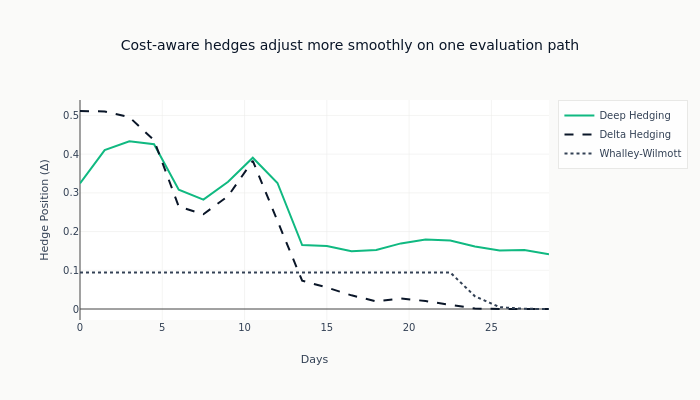

In [35]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=times, y=deep_hedges, name="Deep Hedging", line=dict(color=COLORS["positive"]))
)
fig.add_trace(
    go.Scatter(
        x=times,
        y=delta_hedges,
        name="Delta Hedging",
        line=dict(color=COLORS["blue"], dash="dash"),
    )
)
if np.isfinite(np.asarray(ww_hedges)).any():
    fig.add_trace(
        go.Scatter(
            x=times,
            y=ww_hedges,
            name="Whalley-Wilmott",
            line=dict(color=COLORS["neutral"], dash="dot"),
        )
    )
fig.update_layout(
    title="Cost-aware hedges adjust more smoothly on one evaluation path",
    xaxis_title="Days",
    yaxis_title="Hedge Position (Δ)",
    height=400,
)
fig.show()

## 8. Value-Based Baseline: Tabular Q-Learning

This section provides a compact value-based baseline inspired by the
discrete-time mean-variance setup in Halperin (2019). It is a simple
tabular benchmark, not a full reproduction of the QLBS paper.

Key differences:
- **Method**: Q-learning (value-based) vs policy gradient (actor-critic)
- **Learns**: Q-function directly, derives policy as $\pi(s) = \arg\max_a Q(s, a)$
- **Reward**: Quadratic (mean-variance) for tractability
- **Price**: Emerges from the optimal hedging cost

The quadratic reward penalizes both expected cost and its variance:

$$R(c) = -\mathbb{E}[C] - \lambda \operatorname{Var}[C] \approx -c - \lambda c^2$$

where $c$ is the step cost (transaction cost plus hedge P&L contribution)
and $\lambda$ controls risk aversion. This simplified objective keeps the
baseline compact enough for a single teaching notebook.

### State Discretization Helper

The tabular baseline uses discrete Q-learning, which requires discretizing the continuous
state space into bins for moneyness, time-to-maturity, and previous hedge.

In [36]:
def qlbs_get_state_idx(S, t, prev_hedge_idx, strike, dt, maturity, moneyness_bins, time_bins):
    """Convert continuous state to discrete bin indices for tabular Q-learning."""
    n_moneyness_bins = len(moneyness_bins)
    n_time_bins = len(time_bins)

    log_moneyness = np.log(S / strike)
    m_idx = np.clip(np.digitize(log_moneyness, moneyness_bins) - 1, 0, n_moneyness_bins - 1)

    time_ratio = t * dt / maturity
    t_idx = np.clip(np.digitize(time_ratio, time_bins) - 1, 0, n_time_bins - 1)

    return (m_idx, t_idx, prev_hedge_idx)

### Quadratic hedging reward

The per-step reward penalizes both the cost magnitude and its square,
mirroring a mean-variance objective.

In [37]:
def qlbs_reward(cost: float, risk_aversion: float) -> float:
    """Quadratic hedging reward: penalize cost level and its square."""
    return -cost - risk_aversion * cost**2

### Tabular Q-Learning Training Loop

Train a tabular Q-function over simulated paths using epsilon-greedy
exploration and the quadratic reward above. State discretization uses the
module-level `qlbs_get_state_idx`; the returned `policy` closure looks up the
greedy action for the learned Q-table.

A single-path update isolates the temporal-difference target and terminal
option settlement from the outer simulation loop.

In [38]:
def update_qlbs_path(
    Q,
    prices,
    hedge_values,
    strike,
    dt,
    maturity,
    cost_rate,
    risk_aversion,
    learning_rate,
    discount,
    exploration_rate,
) -> None:
    """Apply tabular Q-learning updates along one simulated price path."""
    n_hedge_bins = len(hedge_values)
    m_bins = np.linspace(-0.3, 0.3, Q.shape[0])
    t_bins = np.linspace(0, 1, Q.shape[1])
    prev_h = n_hedge_bins // 2
    for t in range(len(prices) - 1):
        state = qlbs_get_state_idx(prices[t], t, prev_h, strike, dt, maturity, m_bins, t_bins)
        action = (
            np.random.randint(n_hedge_bins)
            if np.random.random() < exploration_rate
            else np.argmax(Q[state])
        )
        step_cost = cost_rate * abs(hedge_values[action] - hedge_values[prev_h]) * prices[t]
        reward = qlbs_reward(
            step_cost - hedge_values[action] * (prices[t + 1] - prices[t]), risk_aversion
        )
        if t < len(prices) - 2:
            next_state = qlbs_get_state_idx(
                prices[t + 1], t + 1, action, strike, dt, maturity, m_bins, t_bins
            )
            target = reward + discount * np.max(Q[next_state])
        else:
            terminal_value = hedge_values[action] * prices[-1] - max(prices[-1] - strike, 0)
            terminal_value -= cost_rate * abs(hedge_values[action]) * prices[-1]
            target = qlbs_reward(-terminal_value, risk_aversion)
        Q[state + (action,)] += learning_rate * (target - Q[state + (action,)])
        prev_h = action

The outer learner initializes the discrete state-action table, applies each
independent path update, and returns the resulting greedy lookup policy.

In [39]:
def qlbs_hedging(
    prices: np.ndarray,
    strike: float,
    maturity: float,
    cost_rate: float,
    risk_aversion: float = 1.0,
    n_hedge_bins: int = 11,
    learning_rate: float = 0.1,
    discount: float = 0.99,
) -> dict:
    """Train a simple tabular Q-learning hedge policy."""
    n_paths, n_times = prices.shape
    dt = maturity / (n_times - 1)
    hedge_values = np.linspace(0, 1, n_hedge_bins)
    n_m, n_t = 7, 5
    m_bins = np.linspace(-0.3, 0.3, n_m)
    t_bins = np.linspace(0, 1, n_t)
    Q = np.zeros((n_m, n_t, n_hedge_bins, n_hedge_bins))

    for path_idx, price_path in enumerate(prices):
        update_qlbs_path(
            Q,
            price_path,
            hedge_values,
            strike,
            dt,
            maturity,
            cost_rate,
            risk_aversion,
            learning_rate,
            discount,
            max(0.1, 1.0 - path_idx / (n_paths * 0.5)),
        )

    def learned_policy(S, t, prev_hedge_idx):
        state = qlbs_get_state_idx(S, t, prev_hedge_idx, strike, dt, maturity, m_bins, t_bins)
        a = np.argmax(Q[state])
        return hedge_values[a], a

    return {"Q": Q, "policy": learned_policy, "hedge_values": hedge_values}

### Train Tabular Q-Learning

The value-based baseline is trained on its **own** independently simulated
paths (a different seed from the evaluation set) and then evaluated on the
held-out `test_prices`. Training and evaluating on the same paths would
overstate the policy by letting it memorize the realized price path.

In [40]:
set_global_seeds(SEED)

qlbs_train_option = simulate_option(config["eval_seed"] + 10_000, config["n_paths"])
qlbs_train_prices = qlbs_train_option.ul().spot.detach().cpu().numpy() * config["spot"]

qlbs_result = qlbs_hedging(
    qlbs_train_prices,
    strike=config["strike"],
    maturity=config["maturity"],
    cost_rate=config["cost_bps"] / 10_000,
    risk_aversion=0.5,
)

print("Q-learning training complete (trained on independent paths).")
print(f"Q-table shape: {qlbs_result['Q'].shape}")

Q-learning training complete (trained on independent paths).
Q-table shape: (7, 5, 11, 11)


### Evaluate the Value-Based Baseline

Roll the greedy policy ($\arg\max_a Q(s, a)$) through held-out test paths
to produce a P&L distribution comparable to the delta and deep hedging baselines.

In [41]:
def evaluate_qlbs(prices, qlbs_result, strike, maturity, cost_rate):
    """Evaluate the tabular Q-learning policy on test paths."""
    n_paths, n_times = prices.shape
    policy = qlbs_result["policy"]
    n_hedge_bins = len(qlbs_result["hedge_values"])
    positions = np.zeros((n_paths, n_times - 1))
    for path_idx in range(n_paths):
        S = prices[path_idx]
        prev_hedge_idx = n_hedge_bins // 2

        for t in range(n_times - 1):
            new_hedge, new_hedge_idx = policy(S[t], t, prev_hedge_idx)
            positions[path_idx, t] = new_hedge
            prev_hedge_idx = new_hedge_idx

    return hedging_pnl_from_positions(
        prices=prices,
        positions=positions,
        strike=strike,
        cost_rate=cost_rate,
    )

In [42]:
qlbs_pnl = evaluate_qlbs(
    test_prices,
    qlbs_result,
    strike=config["strike"],
    maturity=config["maturity"],
    cost_rate=config["cost_bps"] / 10_000,
)

print("\nTabular Q-Learning P&L Statistics:")
print(f"  Mean:    {np.mean(qlbs_pnl):.4f}")
print(f"  Std Dev: {np.std(qlbs_pnl):.4f}")
print(f"  5% CVaR: {np.mean(qlbs_pnl[qlbs_pnl <= np.percentile(qlbs_pnl, 5)]):.4f}")


Tabular Q-Learning P&L Statistics:
  Mean:    -2.8142
  Std Dev: 2.4002
  5% CVaR: -8.3950


## 9. Compare All Hedging Methods

In [43]:
methods = {
    "Delta Hedging": delta_pnl,
    "Deep Hedging": deep_pnl,
    "Tabular Q-Learning": qlbs_pnl,
}
if ww_pnl is not None:
    methods["Whalley-Wilmott"] = ww_pnl

comparison = []
for name, pnl in methods.items():
    comparison.append(
        {
            "Strategy": name,
            "Mean P&L": f"{np.mean(pnl):.4f}",
            "Std Dev": f"{np.std(pnl):.4f}",
            "5% CVaR": f"{np.mean(pnl[pnl <= np.percentile(pnl, 5)]):.4f}",
            "Max Loss": f"{np.min(pnl):.4f}",
        }
    )

comparison_df = pl.DataFrame(comparison)
comparison_df

Strategy,Mean P&L,Std Dev,5% CVaR,Max Loss
str,str,str,str,str
"""Delta Hedging""","""-2.4488""","""0.5302""","""-3.7339""","""-6.4471"""
"""Deep Hedging""","""-2.3854""","""0.8698""","""-4.1788""","""-6.0862"""
"""Tabular Q-Learning""","""-2.8142""","""2.4002""","""-8.3950""","""-13.9013"""
"""Whalley-Wilmott""","""-2.3387""","""1.6112""","""-5.3616""","""-8.9262"""


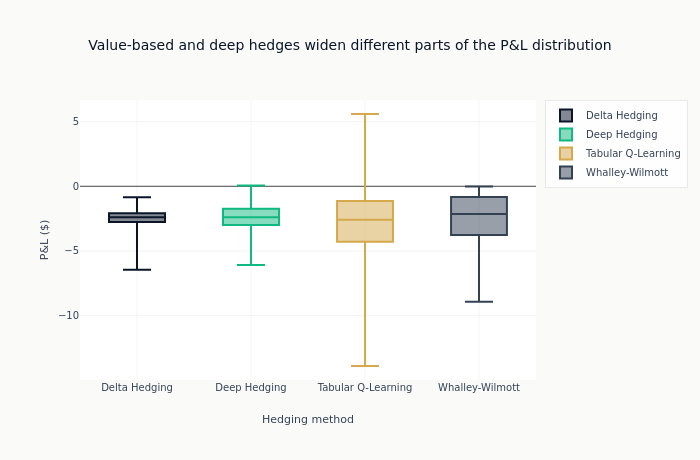

In [44]:
# Distribution comparison with boxes and all tails retained.
fig = go.Figure()

colors = {
    "Delta Hedging": COLORS["blue"],
    "Whalley-Wilmott": COLORS["neutral"],
    "Tabular Q-Learning": COLORS["amber"],
    "Deep Hedging": COLORS["positive"],
}

for name, pnl in methods.items():
    fig.add_trace(
        go.Box(
            y=pnl,
            name=name,
            marker_color=colors[name],
            boxpoints=False,
        )
    )

fig.update_layout(
    title="Value-based and deep hedges widen different parts of the P&L distribution",
    xaxis_title="Hedging method",
    yaxis_title="P&L ($)",
    height=460,
)

fig.show()

Export summaries retain the representative training seed and use the same
tail statistics shown in the notebook.

In [45]:
def hedging_summary_rows() -> list[dict]:
    """Build one machine-readable summary row per hedging method."""
    rows = [
        {
            "strategy": "Delta Hedging",
            "mean_pnl": float(delta_stats["mean"]),
            "std_pnl": float(delta_stats["std"]),
            "cvar_5": float(delta_stats["cvar_5"]),
            "max_loss": float(delta_stats["max_loss"]),
        }
    ]
    if ww_pnl is not None:
        rows.append({"strategy": "Whalley-Wilmott", **{k: float(v) for k, v in ww_stats.items()}})
    rows.extend(
        [
            {
                "strategy": "Deep Hedging",
                "mean_pnl": float(deep_stats["mean"]),
                "std_pnl": float(deep_stats["std"]),
                "cvar_5": float(deep_stats["cvar_5"]),
                "max_loss": float(deep_stats["max_loss"]),
                "seed": representative_seed,
            },
            {
                "strategy": "Tabular Q-Learning",
                "mean_pnl": float(np.mean(qlbs_pnl)),
                "std_pnl": float(np.std(qlbs_pnl)),
                "cvar_5": float(np.mean(qlbs_pnl[qlbs_pnl <= np.percentile(qlbs_pnl, 5)])),
                "max_loss": float(np.min(qlbs_pnl)),
            },
        ]
    )
    return rows

The representative path export uses the same aligned arrays as the trajectory
figure and preserves missing analytical hedges as nulls.

In [46]:
def hedge_trajectory_rows() -> list[dict]:
    """Build aligned representative-path hedge records."""
    return [
        {
            "time_days": float(time_day),
            "deep_hedge": float(deep_hedge),
            "delta_hedge": float(delta_hedge),
            "ww_hedge": float(ww_hedge) if np.isfinite(ww_hedge) else None,
        }
        for time_day, deep_hedge, delta_hedge, ww_hedge in zip(
            times, deep_hedges, delta_hedges, ww_hedges, strict=False
        )
    ]

In [47]:
if config["export_results"]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    pnl_rows = [
        {"strategy": strategy, "path_idx": path_idx, "pnl": float(value)}
        for strategy, pnl in methods.items()
        for path_idx, value in enumerate(np.asarray(pnl).tolist())
    ]
    pl.DataFrame(pnl_rows).write_parquet(OUTPUT_DIR / "hedging_pnl_distributions.parquet")
    pl.DataFrame(hedging_summary_rows()).write_parquet(OUTPUT_DIR / "hedging_summary.parquet")
    pl.DataFrame(hedge_trajectory_rows()).write_parquet(OUTPUT_DIR / "hedge_trajectory.parquet")
    deep_seed_summary.write_parquet(OUTPUT_DIR / "deep_hedging_seed_summary.parquet")
    print(f"Results saved to {OUTPUT_DIR}")

## Key Takeaways

1. **Matched objective and metric**: The `pfhedge` model is trained with an
   expected-shortfall criterion and evaluated with tail-risk statistics, so
   the objective and diagnostics are aligned.

2. **Friction-aware benchmarks**: Black-Scholes delta and Whalley-Wilmott
   provide analytical baselines for the same frictional setting, which makes
   it easier to see when a learned hedge adds value.

3. **Heston for pfhedge, GBM for the from-scratch reference**: The pfhedge
   underlier is configured as a Heston stochastic-volatility process
   (parameters in the config dict above). The §3b from-scratch reference run
   uses GBM with the same volatility. The §6 summary reports both rows
   together, but their P&L distributions are not directly comparable because
   the underlying simulator differs. A controlled Heston-vs-GBM training
   comparison is left to Section 21.6.

4. **Seed stability matters**: Reporting multiple training seeds reduces the
   risk of overinterpreting a single favorable run. The representative seed
   is selected by validation CVaR before the separate held-out evaluation is
   inspected.

5. **Value-based baseline**: The tabular benchmark is useful for intuition,
   but a faithful QLBS reproduction would require a more specialized setup
   than this compact notebook.

**Next**: See Section 21.6 for detailed discussion of deep hedging with RL.